In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

%matplotlib inline

In [2]:
def adf_test(series, title=''):
    if title:
        print(f"\n--- {title} ---")
        
    dftest = adfuller(series.dropna(), autolag='AIC')
    dfoutput = pd.Series(
        dftest[0:4], 
        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    )
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value

    print(dfoutput)
    
    p_value = dftest[1]
    if p_value <= 0.05:
        print("\n=> Result: Data Stationary hai (Reject Null Hypothesis)")
    else:
        print("\n=> Result: Data Non-Stationary hai (Fail to reject Null Hypothesis)")

In [3]:
# File load karein
data = pd.read_csv('TimeSeries_TotalSolarGen_and_Load_IT_2016.csv')

# Datetime conversion aur index set karein
data['utc_timestamp'] = pd.to_datetime(data['utc_timestamp'])
data.set_index('utc_timestamp', inplace=True)

# Missing values handle karein
data['IT_load_new'] = data['IT_load_new'].ffill().bfill()
data['IT_solar_generation'] = data['IT_solar_generation'].ffill().bfill()

data.head()

,IT_load_new,IT_solar_generation
utc_timestamp,,
2016-01-01 00:00:00+00:00,21665.0,1
2016-01-01 01:00:00+00:00,20260.0,0
2016-01-01 02:00:00+00:00,19056.0,0
2016-01-01 03:00:00+00:00,18407.0,0
2016-01-01 04:00:00+00:00,18425.0,0


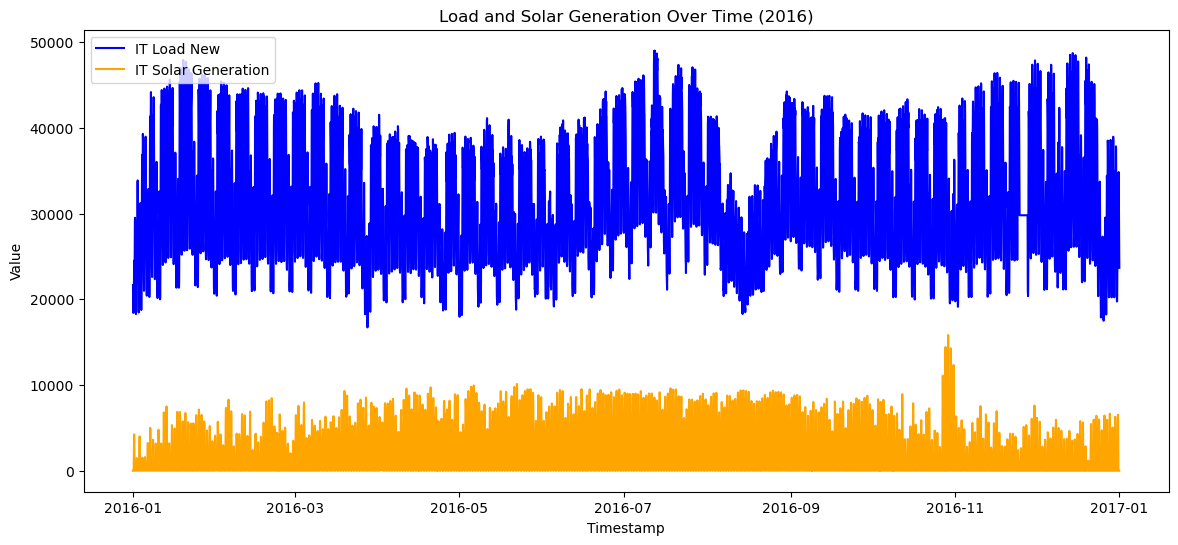

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(data['IT_load_new'], label='IT Load New', color='blue')
plt.plot(data['IT_solar_generation'], label='IT Solar Generation', color='orange')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Load and Solar Generation Over Time (2016)')
plt.legend()
plt.show()

In [5]:
adf_test(data['IT_load_new'], title="ADF test for 'IT_load_new'")
adf_test(data['IT_solar_generation'], title="ADF test for 'IT_solar_generation'")


--- ADF test for 'IT_load_new' ---
Test Statistic                -1.197390e+01
p-value                        3.841445e-22
#Lags Used                     3.700000e+01
Number of Observations Used    8.746000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861871e+00
Critical Value (10%)          -2.566946e+00
dtype: float64

=> Result: Data Stationary hai (Reject Null Hypothesis)

--- ADF test for 'IT_solar_generation' ---
Test Statistic                -5.741335e+00
p-value                        6.265438e-07
#Lags Used                     3.600000e+01
Number of Observations Used    8.747000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861870e+00
Critical Value (10%)          -2.566946e+00
dtype: float64

=> Result: Data Stationary hai (Reject Null Hypothesis)


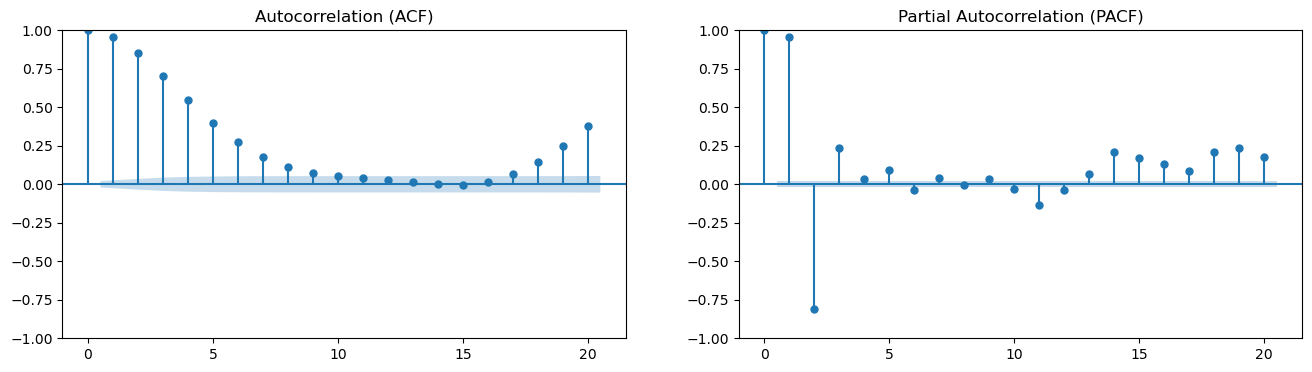

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(data['IT_load_new'], ax=axes[0], lags=20)
axes[0].set_title('Autocorrelation (ACF)')

plot_pacf(data['IT_load_new'], ax=axes[1], lags=20)
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.show()

In [7]:
# 80-20 Train-Test split
train_size = int(len(data) * 0.8)
train = data['IT_load_new'].iloc[:train_size]
test = data['IT_load_new'].iloc[train_size:]

# ARIMA (p=2, d=0, q=2) model fit
model = ARIMA(train, order=(2, 0, 2))
model_fit = model.fit()

# Prediction
predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# RMSE calculate
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f"\nTest RMSE: {rmse:.4f}")

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)



Test RMSE: 7714.9521


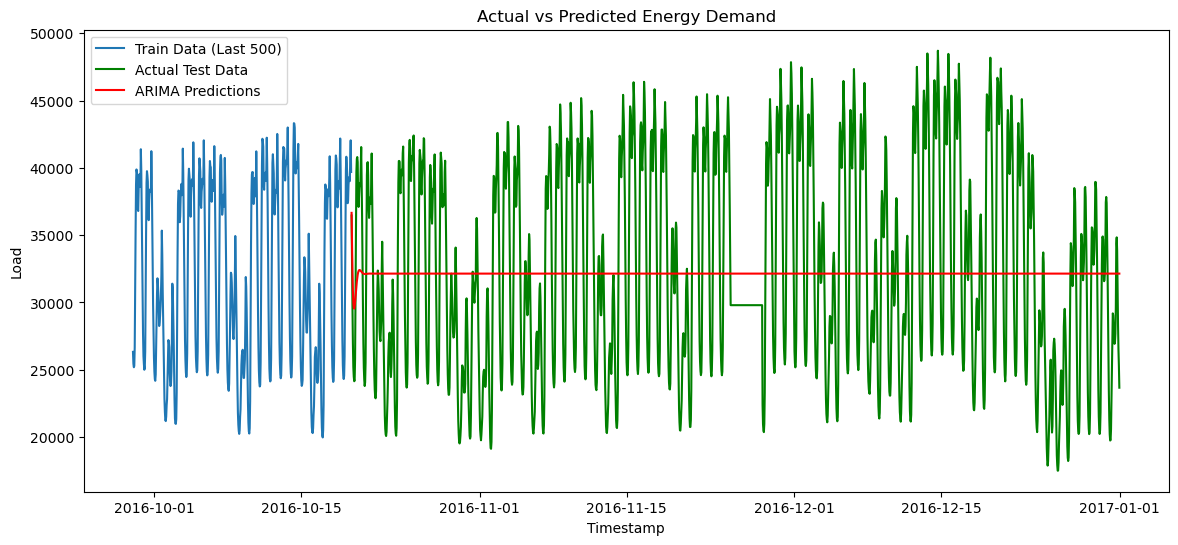

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(train.index[-500:], train.iloc[-500:], label='Train Data (Last 500)')
plt.plot(test.index, test, label='Actual Test Data', color='green')
plt.plot(test.index, predictions, label='ARIMA Predictions', color='red')
plt.title("Actual vs Predicted Energy Demand")
plt.xlabel('Timestamp')
plt.ylabel('Load')
plt.legend()
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


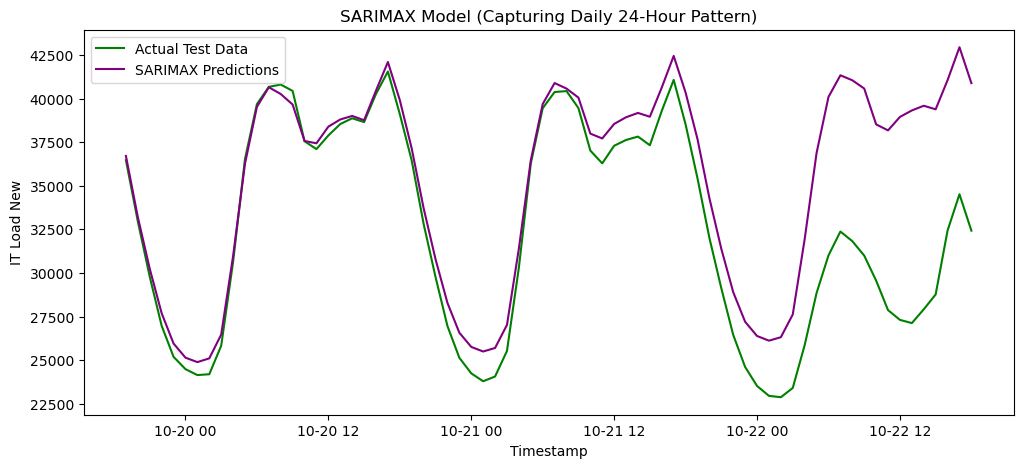

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 24-hour daily seasonality set kar rahe hain (m=24)
# (P, D, Q, s) = (1, 1, 1, 24)
sarima_model = SARIMAX(
    train.iloc[-24*14:],  # Training speed ke liye last 14 days ka sample
    order=(1, 1, 1), 
    seasonal_order=(1, 1, 1, 24)
)

sarima_fit = sarima_model.fit(disp=False)

# Next 3 days (72 hours) ke liye prediction
sarima_preds = sarima_fit.predict(start=len(train.iloc[-24*14:]), end=len(train.iloc[-24*14:]) + 71)

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(test.iloc[:72].index, test.iloc[:72], label='Actual Test Data', color='green')
plt.plot(test.iloc[:72].index, sarima_preds, label='SARIMAX Predictions', color='purple')
plt.title("SARIMAX Model (Capturing Daily 24-Hour Pattern)")
plt.xlabel("Timestamp")
plt.ylabel("IT Load New")
plt.legend()
plt.show()

In [13]:
# Daily / Raw sales data ko Monthly Revenue mein convert karna
monthly_revenue = data['IT_load_new'].resample('MS').sum()  # 'MS' = Month Start

# Data preview
print(monthly_revenue.head())

utc_timestamp
2016-01-01 00:00:00+00:00    24373957.0
2016-02-01 00:00:00+00:00    23455365.0
2016-03-01 00:00:00+00:00    23839492.0
2016-04-01 00:00:00+00:00    21607392.0
2016-05-01 00:00:00+00:00    22466253.0
Freq: MS, Name: IT_load_new, dtype: float64


In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Revenue ke liye Seasonal Order s=12 (12 months in a year) set karenge
revenue_model = SARIMAX(
    monthly_revenue,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

revenue_model_fit = revenue_model.fit(disp=False)
print("Model Summary Loaded Successfully!")

Model Summary Loaded Successfully!


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [15]:
# Aage ke 12 months (Future 1 Year) ke liye forecast
forecast_steps = 12
forecast_object = revenue_model_fit.get_forecast(steps=forecast_steps)

# Forecast summary table (Mean, Lower CI, Upper CI)
forecast_df = forecast_object.summary_frame()
print(forecast_df.head())

IT_load_new                        mean     mean_se  mean_ci_lower  \
2017-01-01 00:00:00+00:00  3.655261e+07  707.107665   3.655122e+07   
2017-02-01 00:00:00+00:00  3.563401e+07  707.108372   3.563263e+07   
2017-03-01 00:00:00+00:00  3.601814e+07  707.109079   3.601675e+07   
2017-04-01 00:00:00+00:00  3.378604e+07  707.109786   3.378465e+07   
2017-05-01 00:00:00+00:00  3.464490e+07  707.110493   3.464352e+07   

IT_load_new                mean_ci_upper  
2017-01-01 00:00:00+00:00   3.655399e+07  
2017-02-01 00:00:00+00:00   3.563540e+07  
2017-03-01 00:00:00+00:00   3.601953e+07  
2017-04-01 00:00:00+00:00   3.378743e+07  
2017-05-01 00:00:00+00:00   3.464629e+07  


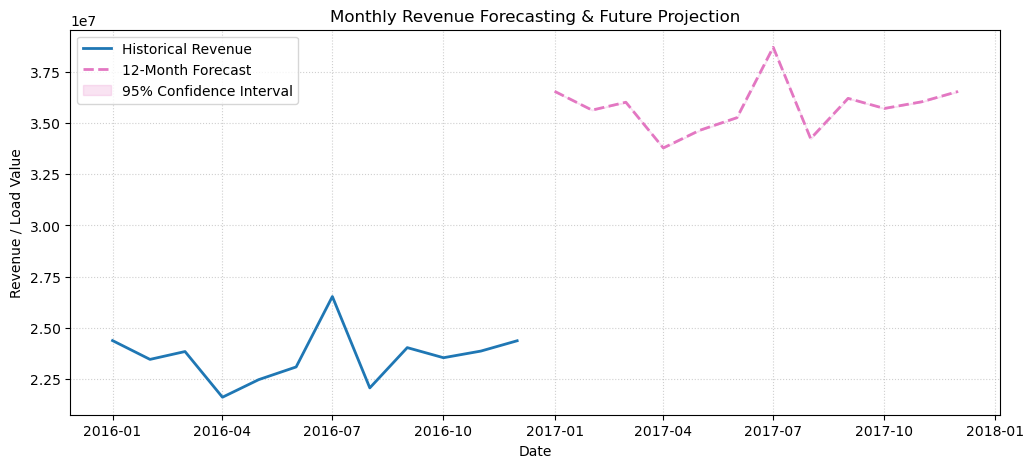

In [16]:
plt.figure(figsize=(12, 5))

# Historical Revenue
plt.plot(monthly_revenue.index, monthly_revenue, label='Historical Revenue', color='#1f77b4', linewidth=2)

# Future Forecast Line
plt.plot(forecast_df.index, forecast_df['mean'], label='12-Month Forecast', color='#e377c2', linewidth=2, linestyle='--')

# Confidence Band (Upper and Lower bounds for Risk Analysis)
plt.fill_between(
    forecast_df.index, 
    forecast_df['mean_ci_lower'], 
    forecast_df['mean_ci_upper'], 
    color='#e377c2', 
    alpha=0.2, 
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecasting & Future Projection')
plt.xlabel('Date')
plt.ylabel('Revenue / Load Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [17]:
import pandas as pd
import numpy as np

# Load Data & Handle Missing Values
df = pd.read_csv('TimeSeries_TotalSolarGen_and_Load_IT_2016.csv')
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])
df.set_index('utc_timestamp', inplace=True)
df['IT_load_new'] = df['IT_load_new'].ffill().bfill()
df['IT_solar_generation'] = df['IT_solar_generation'].ffill().bfill()

# 1. Temporal / Calendar Features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Lag Features (1hr ago, 24hr ago, 1 week ago)
for lag in [1, 2, 3, 24, 48, 168]:
    df[f'lag_{lag}'] = df['IT_load_new'].shift(lag)

# 3. Rolling Window Features
df['rolling_mean_24'] = df['IT_load_new'].shift(1).rolling(window=24).mean()
df['rolling_std_24'] = df['IT_load_new'].shift(1).rolling(window=24).std()

# Drop NA rows created by lag calculations
df.dropna(inplace=True)
df.head()

,IT_load_new,IT_solar_generation,hour,dayofweek,month,quarter,is_weekend,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24
utc_timestamp,,,,,,,,,,,,,,,
2016-01-08 00:00:00+00:00,23911.0,1,0,4,1,1,0,25739.0,28759.0,32432.0,21226.0,22129.0,21665.0,34095.291667,8295.420898
2016-01-08 01:00:00+00:00,23010.0,1,1,4,1,1,0,23911.0,25739.0,28759.0,20395.0,21058.0,20260.0,34207.166667,8130.786703
2016-01-08 02:00:00+00:00,22594.0,1,2,4,1,1,0,23010.0,23911.0,25739.0,20269.0,20533.0,19056.0,34316.125000,7953.229021
2016-01-08 03:00:00+00:00,23020.0,0,3,4,1,1,0,22594.0,23010.0,23911.0,20728.0,20421.0,18407.0,34413.000000,7787.112687
2016-01-08 04:00:00+00:00,24660.0,0,4,4,1,1,0,23020.0,22594.0,23010.0,22606.0,20760.0,18425.0,34508.500000,7624.338004


In [18]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Train-Test Split (Chronological 80-20)
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

features = [col for col in df.columns if col not in ['IT_load_new']]
target = 'IT_load_new'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# Train Model
ml_model = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=6, random_state=42)
ml_model.fit(X_train, y_train)

# Evaluation
predictions = ml_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mape = mean_absolute_percentage_error(y_test, predictions) * 100

print(f"Model RMSE Error: {rmse:.2f}")
print(f"Model MAPE Accuracy Score: {100 - mape:.2f}% (MAPE Error: {mape:.2f}%)")

Model RMSE Error: 842.36
Model MAPE Accuracy Score: 98.03% (MAPE Error: 1.97%)


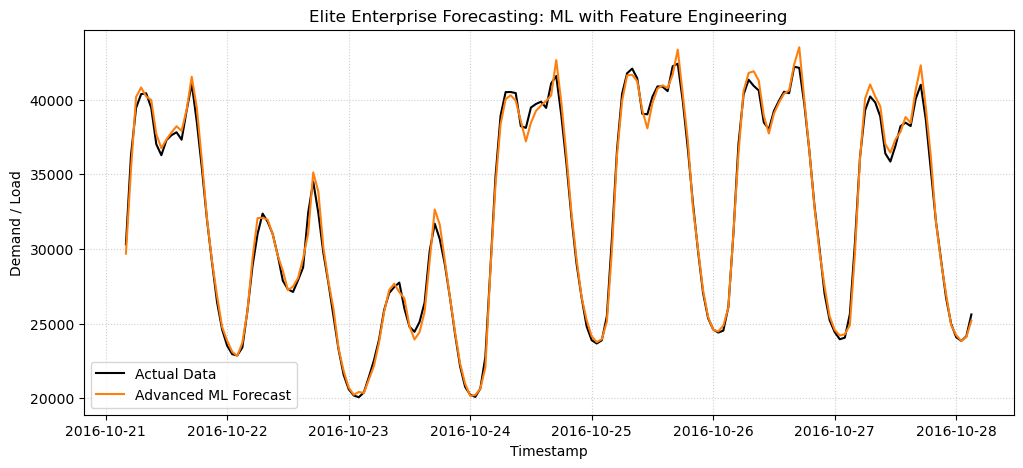

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index[:168], y_test.values[:168], label='Actual Data', color='black', linewidth=1.5)
plt.plot(y_test.index[:168], predictions[:168], label='Advanced ML Forecast', color='tab:orange', linewidth=1.5)

plt.title("Elite Enterprise Forecasting: ML with Feature Engineering")
plt.xlabel("Timestamp")
plt.ylabel("Demand / Load")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

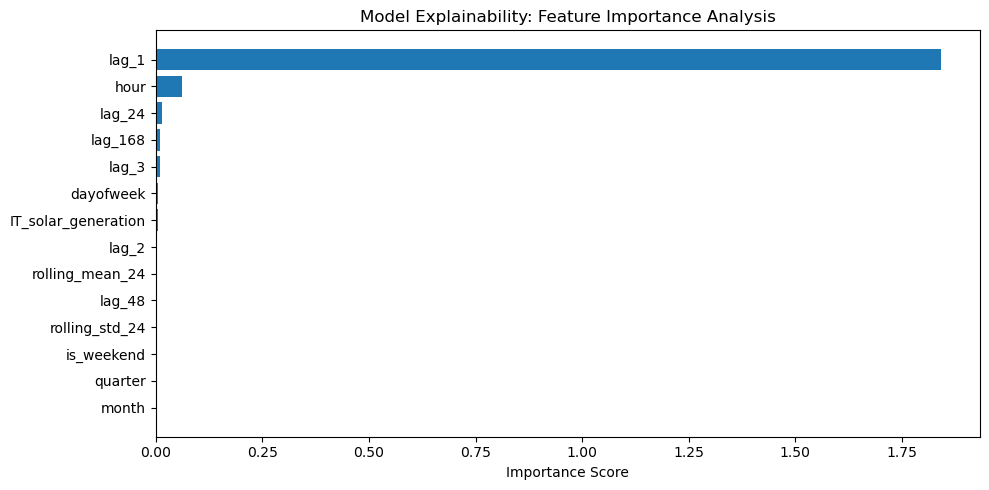

In [20]:
from sklearn.inspection import permutation_importance

# Permutation importance calculate karein
perm_importance = permutation_importance(
    ml_model, 
    X_test, 
    y_test, 
    n_repeats=5, 
    random_state=42
)

# Feature Importance Plot
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10, 5))
plt.barh(np.array(features)[sorted_idx], perm_importance.importances_mean[sorted_idx], color='#1f77b4')
plt.title("Model Explainability: Feature Importance Analysis")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [21]:
import joblib

# Trained model aur feature list save karein
joblib.dump(ml_model, 'forecasting_pipeline_model.pkl')
joblib.dump(features, 'model_features.pkl')

print("Model Pipeline and Features successfully exported to disk!")

Model Pipeline and Features successfully exported to disk!


In [22]:
# Save kiya hua model reload karke test karein
loaded_model = joblib.load('forecasting_pipeline_model.pkl')
loaded_features = joblib.load('model_features.pkl')

# Future sample input prediction
sample_input = X_test[loaded_features].iloc[[0]]
predicted_value = loaded_model.predict(sample_input)

print(f"Sample Input Timestamp: {sample_input.index[0]}")
print(f"Predicted Demand/Revenue Load: {predicted_value[0]:.2f}")

Sample Input Timestamp: 2016-10-21 04:00:00+00:00
Predicted Demand/Revenue Load: 29689.90
